In [2]:
!pip install timm torchmetrics albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 19.4 MB/s eta 0:00:00


Using device : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
Model        : vit_base_patch16_224
Using Colab cache for faster access to the 'ocular-disease-recognition-odir5k' dataset.
Dataset path : /kaggle/input/ocular-disease-recognition-odir5k
Excel shape  : (3500, 15)
Columns      : ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Image dir    : /kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images  (7000 images)
Left col     : Left-Fundus
Right col    : Right-Fundus
Label cols   : ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Total samples: 7000  (skipped 0 missing images)
Train        : 5600  Val: 1400


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Parameters   : 85,804,808

Epoch [01/10]  lr=3.00e-04
-------------------------------------------------------


  Train Loss : 0.3663
  Val   Loss : 0.3476
  Macro AUC  : 0.6382
  Macro mAP  : 0.2245
  Macro F1   : 0.0133
  ✓ Best model saved  (AUC = 0.6382)

Epoch [02/10]  lr=2.93e-04
-------------------------------------------------------


  Train Loss : 0.3535
  Val   Loss : 0.3409
  Macro AUC  : 0.6753
  Macro mAP  : 0.2557
  Macro F1   : 0.0295
  ✓ Best model saved  (AUC = 0.6753)

Epoch [03/10]  lr=2.71e-04
-------------------------------------------------------


...

  Train Loss : 0.3306
  Val   Loss : 0.3205
  Macro AUC  : 0.7133
  Macro mAP  : 0.3623
  Macro F1   : 0.1219

Epoch [07/10]  lr=1.04e-04
-------------------------------------------------------


  Train Loss : 0.3234
  Val   Loss : 0.3173
  Macro AUC  : 0.7307
  Macro mAP  : 0.3852
  Macro F1   : 0.1793
  ✓ Best model saved  (AUC = 0.7307)

Epoch [08/10]  lr=6.18e-05
-------------------------------------------------------


  Train Loss : 0.3166
  Val   Loss : 0.3129
  Macro AUC  : 0.7333
  Macro mAP  : 0.3866
  Macro F1   : 0.2164
  ✓ Best model saved  (AUC = 0.7333)

Epoch [09/10]  lr=2.86e-05
-------------------------------------------------------


  Train Loss : 0.3098
  Val   Loss : 0.3080
  Macro AUC  : 0.7414
  Macro mAP  : 0.4062
  Macro F1   : 0.1831
  ✓ Best model saved  (AUC = 0.7414)

Epoch [10/10]  lr=7.34e-06
-------------------------------------------------------


  Train Loss : 0.3043
  Val   Loss : 0.3058
  Macro AUC  : 0.7429
  Macro mAP  : 0.4124
  Macro F1   : 0.2416
  ✓ Best model saved  (AUC = 0.7429)

Training complete.  Best Validation AUC : 0.7429

Class                AUC      mAP       F1
------------------------------------------
Normal            0.6367   0.4482   0.1362
Diabetes          0.6833   0.4991   0.2642
Glaucoma          0.8319   0.3513   0.2105
Cataract          0.9016   0.6035   0.4667
AMD               0.6425   0.0635   0.0000
Hypertension      0.6979   0.1466   0.1250
Myopia            0.9449   0.7868   0.7304
Others            0.6043   0.4005   0.0000


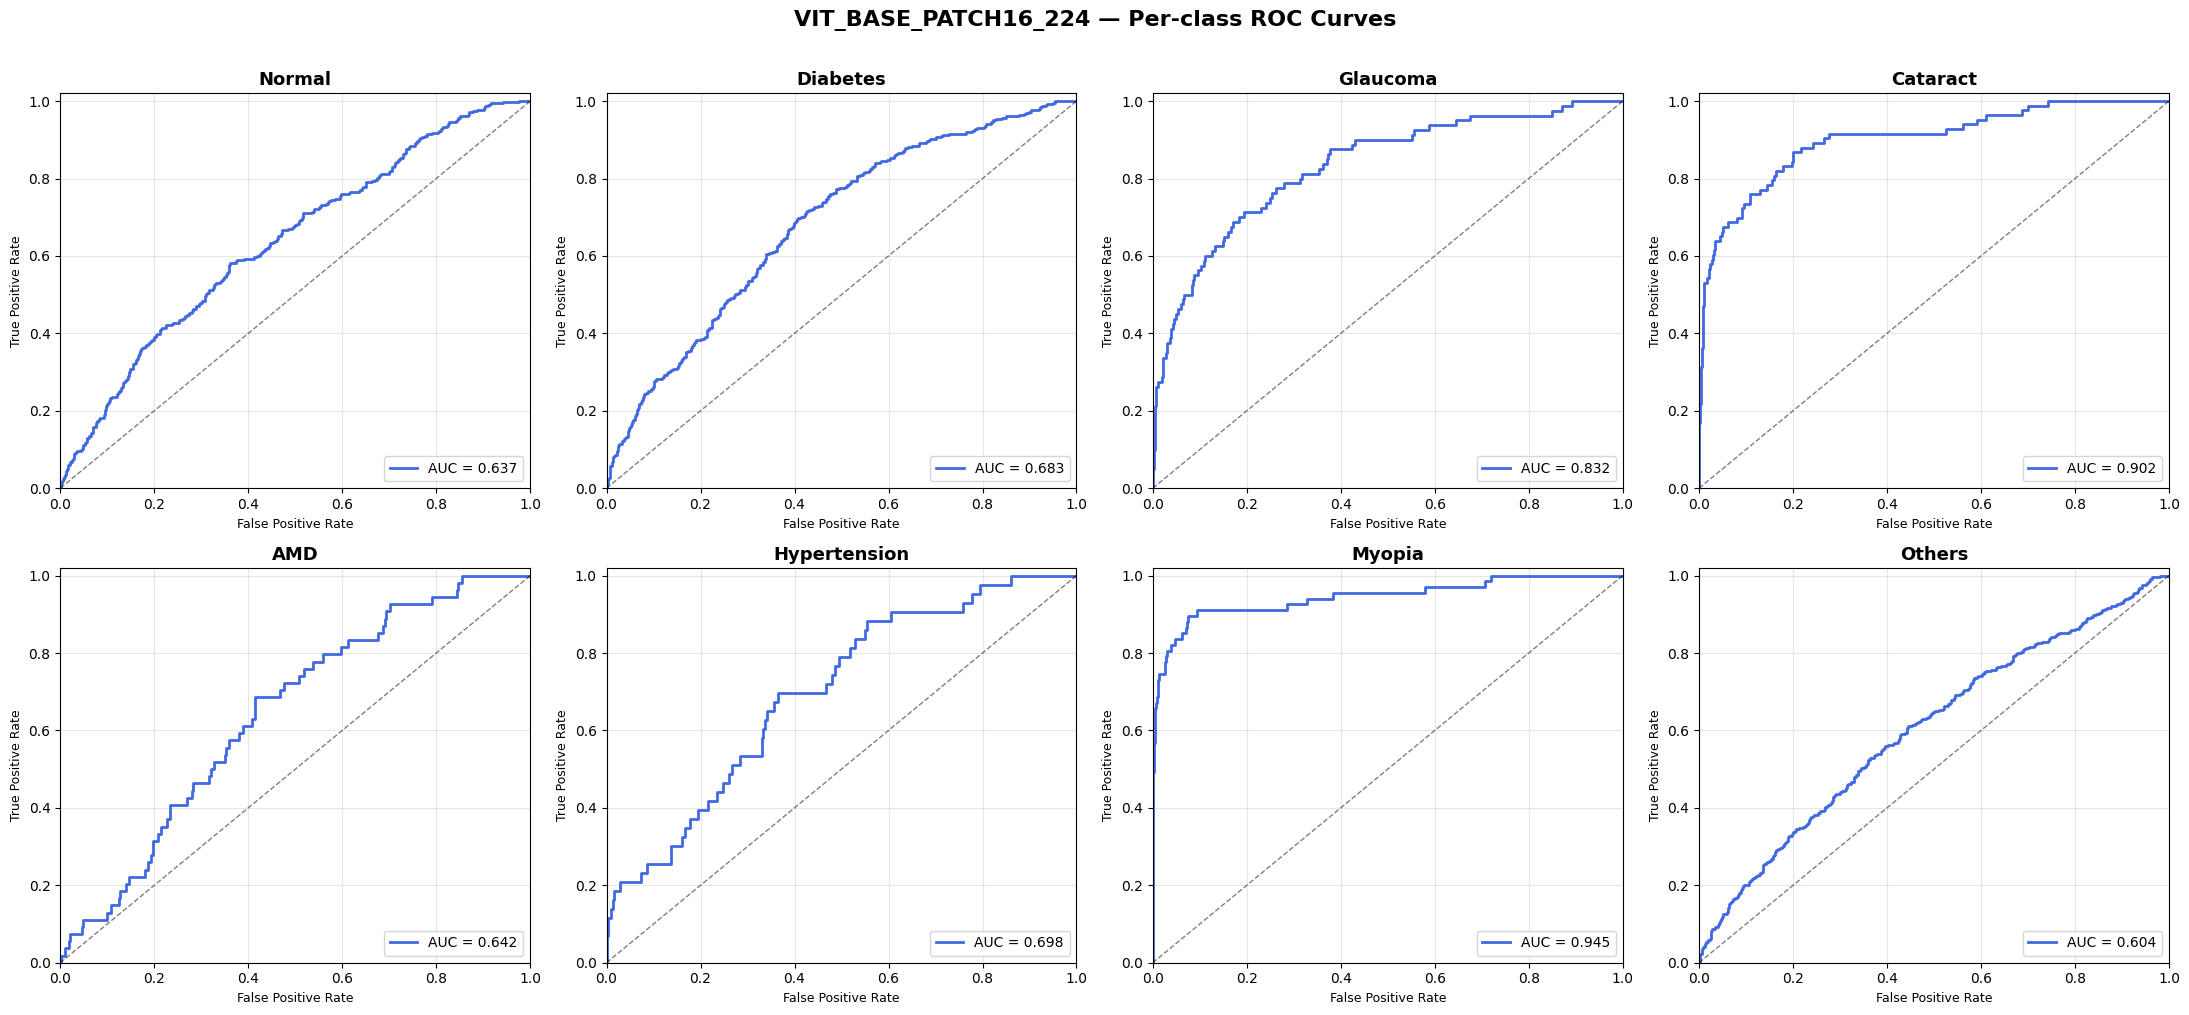

Saved: vit_base_patch16_224_roc_curves.png


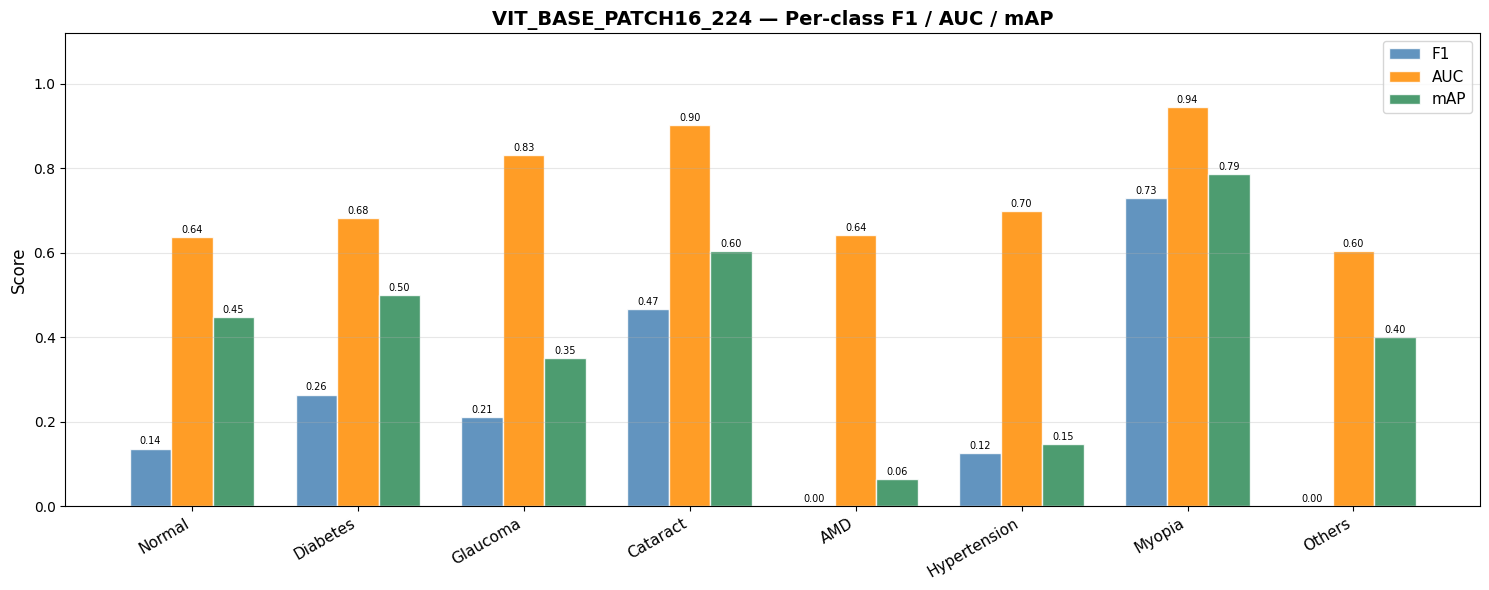

Saved: vit_base_patch16_224_metrics_bar.png


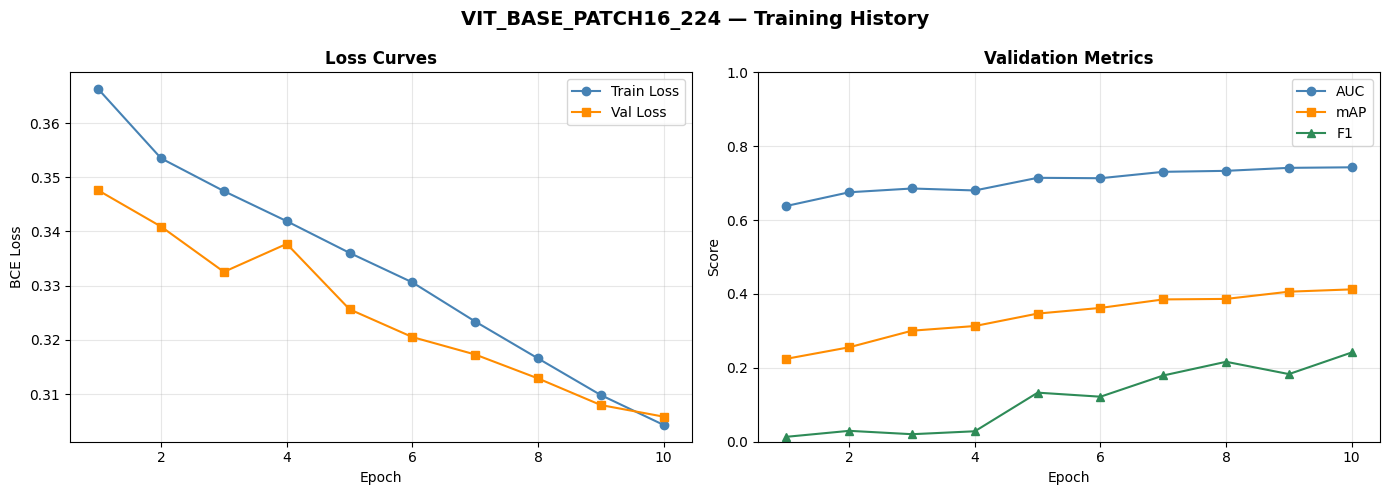

Saved: vit_base_patch16_224_training_curves.png
CUDA cache cleared.


In [4]:
# ============================================================
# MODEL 6: Vision Transformer ViT-Base/16 — ODIR-5K Multi-Label Classification
# FIXED: Uses binary label columns directly, Affine instead of
#        ShiftScaleRotate, verified GPU usage
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
from torchmetrics.classification import (
    MultilabelAUROC, MultilabelAveragePrecision, MultilabelF1Score
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Config ───────────────────────────────────────────────────
MODEL_NAME   = "vit_base_patch16_224"
NUM_CLASSES  = 8
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Sanity-check GPU ─────────────────────────────────────────
print(f"Using device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Enable via Runtime → Change runtime type → GPU")

print(f"Model        : {MODEL_NAME}")

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract",
               "AMD",    "Hypertension", "Myopia", "Others"]

# Label columns already binarised in the Excel
LABEL_COLS  = ["N", "D", "G", "C", "A", "H", "M", "O"]

# ── Download Dataset ─────────────────────────────────────────
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")
print(f"Dataset path : {path}")

# ── Load Labels ──────────────────────────────────────────────
excel_candidates = glob(os.path.join(path, "**", "data.xlsx"), recursive=True)
assert len(excel_candidates) > 0, "data.xlsx not found!"
df = pd.read_excel(excel_candidates[0])
df.columns = [c.strip() for c in df.columns]
print(f"Excel shape  : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")

# ── Find image directory ──────────────────────────────────────
img_dirs = []
for root, dirs, files in os.walk(path):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(imgs) > 10:
        img_dirs.append((root, len(imgs)))
img_dirs.sort(key=lambda x: -x[1])
IMAGE_DIR = img_dirs[0][0]
print(f"Image dir    : {IMAGE_DIR}  ({img_dirs[0][1]} images)")

# ── Helper: resolve image path ───────────────────────────────
def resolve_path(fname):
    """Return full path for a filename, searching recursively if needed."""
    direct = os.path.join(IMAGE_DIR, fname)
    if os.path.exists(direct):
        return direct
    matches = glob(os.path.join(path, "**", fname), recursive=True)
    return matches[0] if matches else None

# ── Build per-eye sample list using binary label columns ──────
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

left_fname_col  = find_col(df, ["Left-Fundus",  "Left Fundus",  "left_fundus"])
right_fname_col = find_col(df, ["Right-Fundus", "Right Fundus", "right_fundus"])
assert left_fname_col  is not None, "Left-Fundus column not found"
assert right_fname_col is not None, "Right-Fundus column not found"
assert all(c in df.columns for c in LABEL_COLS), \
    f"Missing label columns. Found: {df.columns.tolist()}"

print(f"Left col     : {left_fname_col}")
print(f"Right col    : {right_fname_col}")
print(f"Label cols   : {LABEL_COLS}")

samples     = []
missing_cnt = 0

for _, row in df.iterrows():
    label_vec = [int(row[c]) for c in LABEL_COLS]   # already 0/1 integers

    for fname_col in [left_fname_col, right_fname_col]:
        fname = str(row[fname_col]).strip()
        fpath = resolve_path(fname)
        if fpath is None:
            missing_cnt += 1
            continue
        samples.append({"image_path": fpath, "labels": label_vec})

print(f"Total samples: {len(samples)}  (skipped {missing_cnt} missing images)")
assert len(samples) > 100, "Too few samples — check image paths!"

# ── Train / Val Split ─────────────────────────────────────────
train_samples, val_samples = train_test_split(
    samples, test_size=0.2, random_state=SEED
)
print(f"Train        : {len(train_samples)}  Val: {len(val_samples)}")

# ── Albumentations Transforms ─────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=10, p=0.3),
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.4
    ),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Dataset ───────────────────────────────────────────────────
class ODIRDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item  = self.samples[idx]
        image = np.array(Image.open(item["image_path"]).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        labels = torch.tensor(item["labels"], dtype=torch.float32)
        return image, labels

train_dataset = ODIRDataset(train_samples, train_transform)
val_dataset   = ODIRDataset(val_samples,   val_transform)

# pin_memory only useful with CUDA
_pin = DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=_pin)

# ── Model ─────────────────────────────────────────────────────
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")

# ── Loss / Optimizer / Scheduler ─────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── torchmetrics (kept on DEVICE for speed) ───────────────────
metric_auc = MultilabelAUROC(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_map = MultilabelAveragePrecision(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_f1  = MultilabelF1Score(num_labels=NUM_CLASSES, average="macro",
                                threshold=0.5).to(DEVICE)

# ── Train one epoch ───────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, desc="  Train", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}")
    return running_loss / len(loader.dataset)

# ── Validate ──────────────────────────────────────────────────
def validate(model, loader, criterion, device,
             metric_auc, metric_map, metric_f1):
    model.eval()
    running_loss = 0.0
    metric_auc.reset()
    metric_map.reset()
    metric_f1.reset()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Val  ", leave=False):
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            loss    = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            probs   = torch.sigmoid(logits)
            metric_auc.update(probs, labels.int())
            metric_map.update(probs, labels.int())
            metric_f1.update(probs,  labels.int())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    val_loss   = running_loss / len(loader.dataset)
    auc        = metric_auc.compute().item()
    mAP        = metric_map.compute().item()
    f1         = metric_f1.compute().item()
    all_probs  = torch.cat(all_probs,  dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return val_loss, auc, mAP, f1, all_probs, all_labels

# ── Training Loop ─────────────────────────────────────────────
best_auc    = 0.0
best_probs  = None
best_labels = None
history     = {"train_loss": [], "val_loss": [],
               "auc": [],       "map": [],      "f1": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch:02d}/{EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}")
    print("-" * 55)

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)

    val_loss, auc, mAP, f1, probs, labels = validate(
        model, val_loader, criterion, DEVICE,
        metric_auc, metric_map, metric_f1)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["auc"].append(auc)
    history["map"].append(mAP)
    history["f1"].append(f1)

    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Macro AUC  : {auc:.4f}")
    print(f"  Macro mAP  : {mAP:.4f}")
    print(f"  Macro F1   : {f1:.4f}")

    if auc > best_auc:
        best_auc    = auc
        best_probs  = probs.clone()
        best_labels = labels.clone()
        torch.save(model.state_dict(), f"best_{MODEL_NAME}.pth")
        print(f"  ✓ Best model saved  (AUC = {best_auc:.4f})")

print(f"\n{'='*55}")
print(f"Training complete.  Best Validation AUC : {best_auc:.4f}")
print(f"{'='*55}")

# ── Per-class metrics on best checkpoint ─────────────────────
best_probs_np  = best_probs.numpy()
best_labels_np = best_labels.numpy()
best_preds_np  = (best_probs_np >= 0.5).astype(int)

per_class_auc = []
per_class_map = []
per_class_f1  = []

for i in range(NUM_CLASSES):
    try:
        auc_i = roc_auc_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        auc_i = float("nan")
    try:
        map_i = average_precision_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        map_i = float("nan")
    f1_i = f1_score(best_labels_np[:, i], best_preds_np[:, i], zero_division=0)
    per_class_auc.append(auc_i)
    per_class_map.append(map_i)
    per_class_f1.append(f1_i)

print(f"\n{'Class':<15} {'AUC':>8} {'mAP':>8} {'F1':>8}")
print("-" * 42)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {per_class_auc[i]:>8.4f} "
          f"{per_class_map[i]:>8.4f} {per_class_f1[i]:>8.4f}")

# ── Plot 1: Per-class ROC Curves ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    if np.isnan(per_class_auc[i]):
        ax.text(0.5, 0.5, "N/A (single class)",
                ha="center", va="center", transform=ax.transAxes)
    else:
        fpr, tpr, _ = roc_curve(best_labels_np[:, i], best_probs_np[:, i])
        ax.plot(fpr, tpr, color="royalblue", lw=2,
                label=f"AUC = {per_class_auc[i]:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate",  fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Per-class ROC Curves",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_roc_curves.png")

# ── Plot 2: Bar chart F1 / AUC / mAP ─────────────────────────
x     = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
bars_f1  = ax.bar(x - width, per_class_f1,  width,
                  label="F1",  color="steelblue",  alpha=0.85, edgecolor="white")
bars_auc = ax.bar(x,          per_class_auc, width,
                  label="AUC", color="darkorange", alpha=0.85, edgecolor="white")
bars_map = ax.bar(x + width,  per_class_map, width,
                  label="mAP", color="seagreen",   alpha=0.85, edgecolor="white")

# Annotate bar tops
for bars in [bars_f1, bars_auc, bars_map]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h + 0.005,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"{MODEL_NAME.upper()} — Per-class F1 / AUC / mAP",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_metrics_bar.png")

# ── Plot 3: Training curves ───────────────────────────────────
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, history["train_loss"], "o-",
             label="Train Loss", color="steelblue")
axes[0].plot(epochs_x, history["val_loss"],   "s-",
             label="Val Loss",   color="darkorange")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["auc"], "o-", label="AUC", color="steelblue")
axes[1].plot(epochs_x, history["map"], "s-", label="mAP", color="darkorange")
axes[1].plot(epochs_x, history["f1"],  "^-", label="F1",  color="seagreen")
axes[1].set_title("Validation Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Training History",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_training_curves.png")

# ── Cleanup ───────────────────────────────────────────────────
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared.")

Using device : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
Model        : convit_base
Using Colab cache for faster access to the 'ocular-disease-recognition-odir5k' dataset.
Dataset path : /kaggle/input/ocular-disease-recognition-odir5k
Excel shape  : (3500, 15)
Columns      : ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Image dir    : /kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images  (7000 images)
Left col     : Left-Fundus
Right col    : Right-Fundus
Label cols   : ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Total samples: 7000  (skipped 0 missing images)
Train        : 5600  Val: 1400


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Parameters   : 85,777,192

Epoch [01/10]  lr=3.00e-04
-------------------------------------------------------


  Train Loss : 0.3558
  Val   Loss : 0.3453
  Macro AUC  : 0.6605
  Macro mAP  : 0.2753
  Macro F1   : 0.0000
  ✓ Best model saved  (AUC = 0.6605)

Epoch [02/10]  lr=2.93e-04
-------------------------------------------------------


...

  Train Loss : 0.3082
  Val   Loss : 0.3039
  Macro AUC  : 0.7570
  Macro mAP  : 0.4137
  Macro F1   : 0.2241
  ✓ Best model saved  (AUC = 0.7570)

Epoch [07/10]  lr=1.04e-04
-------------------------------------------------------


  Train Loss : 0.3010
  Val   Loss : 0.3049
  Macro AUC  : 0.7703
  Macro mAP  : 0.4439
  Macro F1   : 0.3250
  ✓ Best model saved  (AUC = 0.7703)

Epoch [08/10]  lr=6.18e-05
-------------------------------------------------------


  Train Loss : 0.2918
  Val   Loss : 0.3010
  Macro AUC  : 0.7809
  Macro mAP  : 0.4560
  Macro F1   : 0.3295
  ✓ Best model saved  (AUC = 0.7809)

Epoch [09/10]  lr=2.86e-05
-------------------------------------------------------


  Train Loss : 0.2828
  Val   Loss : 0.2931
  Macro AUC  : 0.7864
  Macro mAP  : 0.4609
  Macro F1   : 0.3505
  ✓ Best model saved  (AUC = 0.7864)

Epoch [10/10]  lr=7.34e-06
-------------------------------------------------------


  Train Loss : 0.2772
  Val   Loss : 0.2915
  Macro AUC  : 0.7882
  Macro mAP  : 0.4686
  Macro F1   : 0.3497
  ✓ Best model saved  (AUC = 0.7882)

Training complete.  Best Validation AUC : 0.7882

Class                AUC      mAP       F1
------------------------------------------
Normal            0.7001   0.4913   0.3423
Diabetes          0.6914   0.5104   0.4106
Glaucoma          0.8746   0.4712   0.4228
Cataract          0.9443   0.7239   0.6000
AMD               0.7410   0.1511   0.0000
Hypertension      0.7444   0.1652   0.1224
Myopia            0.9662   0.8124   0.8031
Others            0.6436   0.4231   0.0961


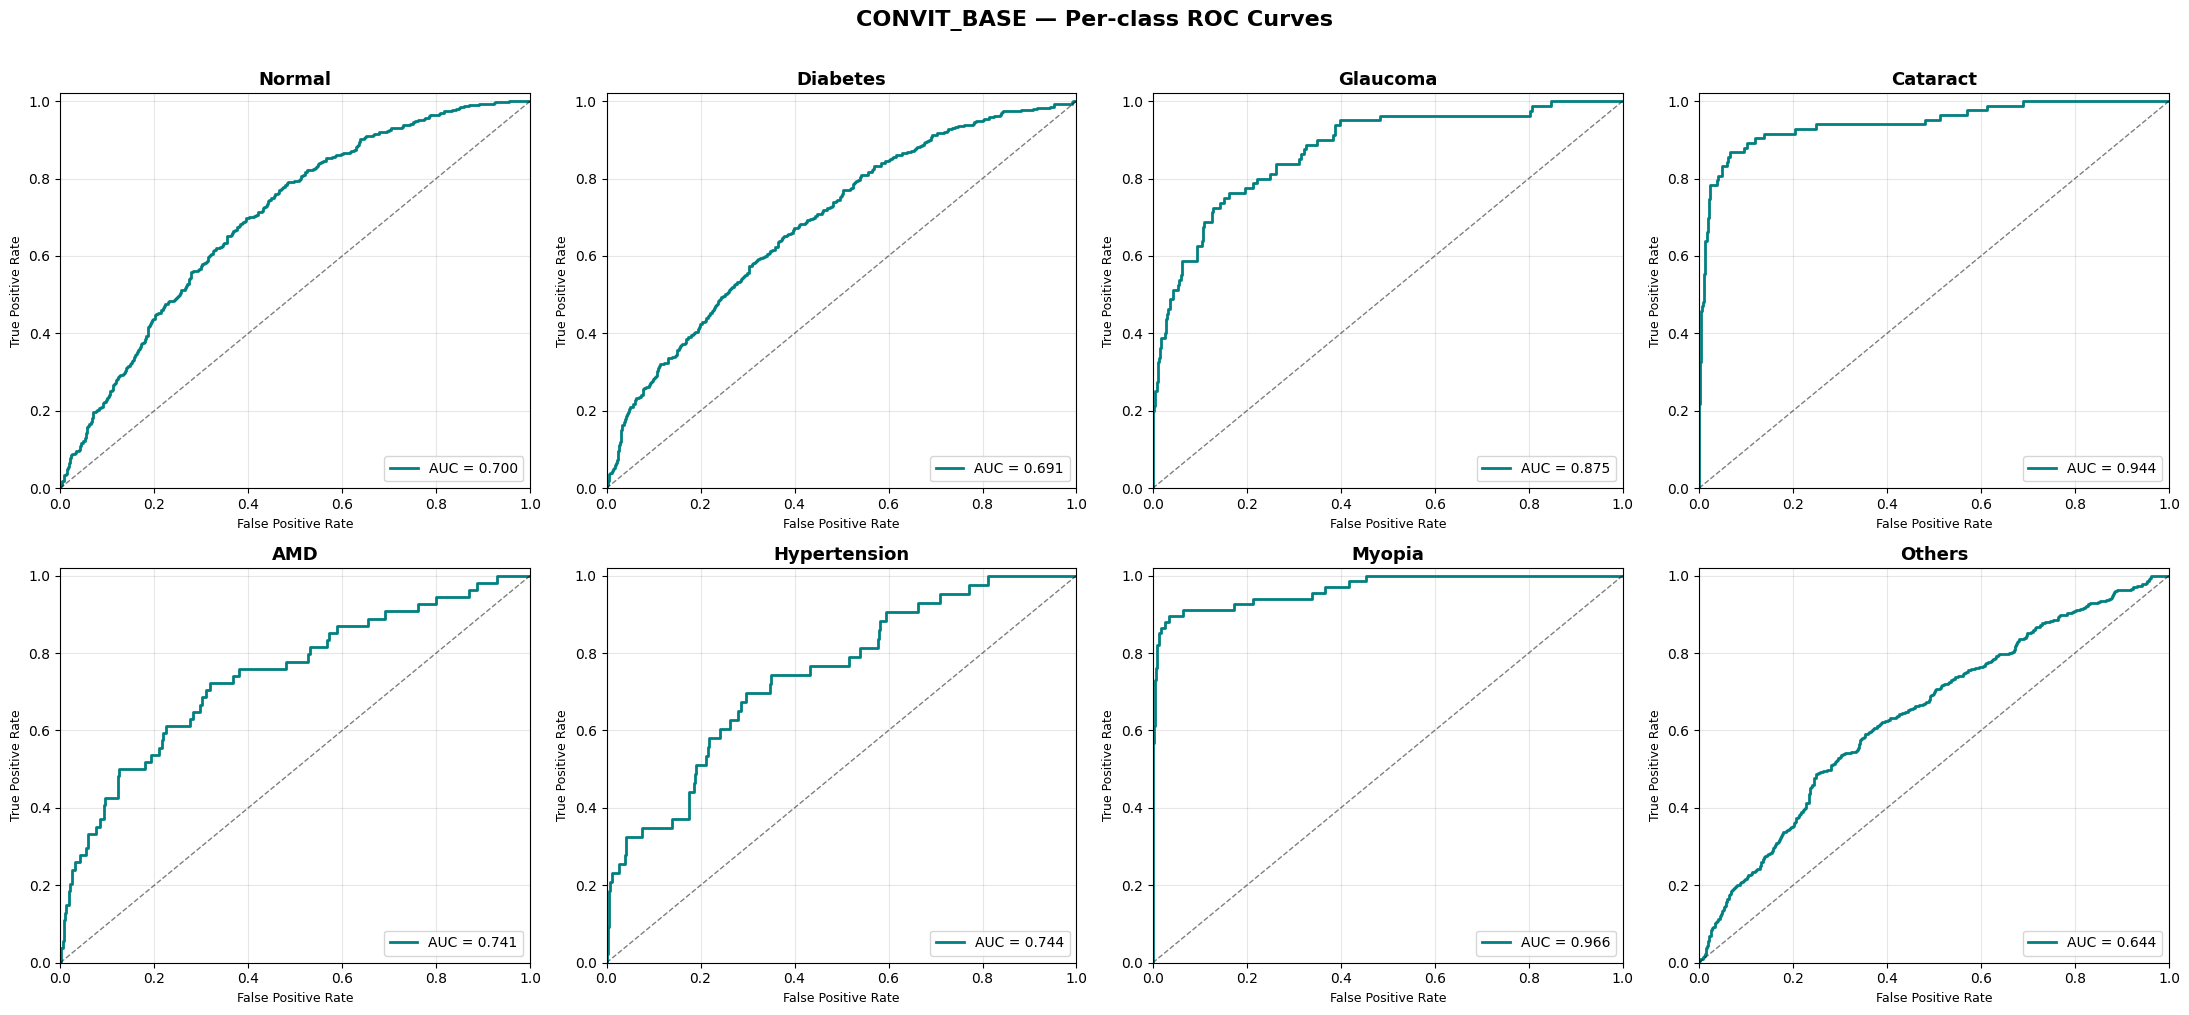

Saved: convit_base_roc_curves.png


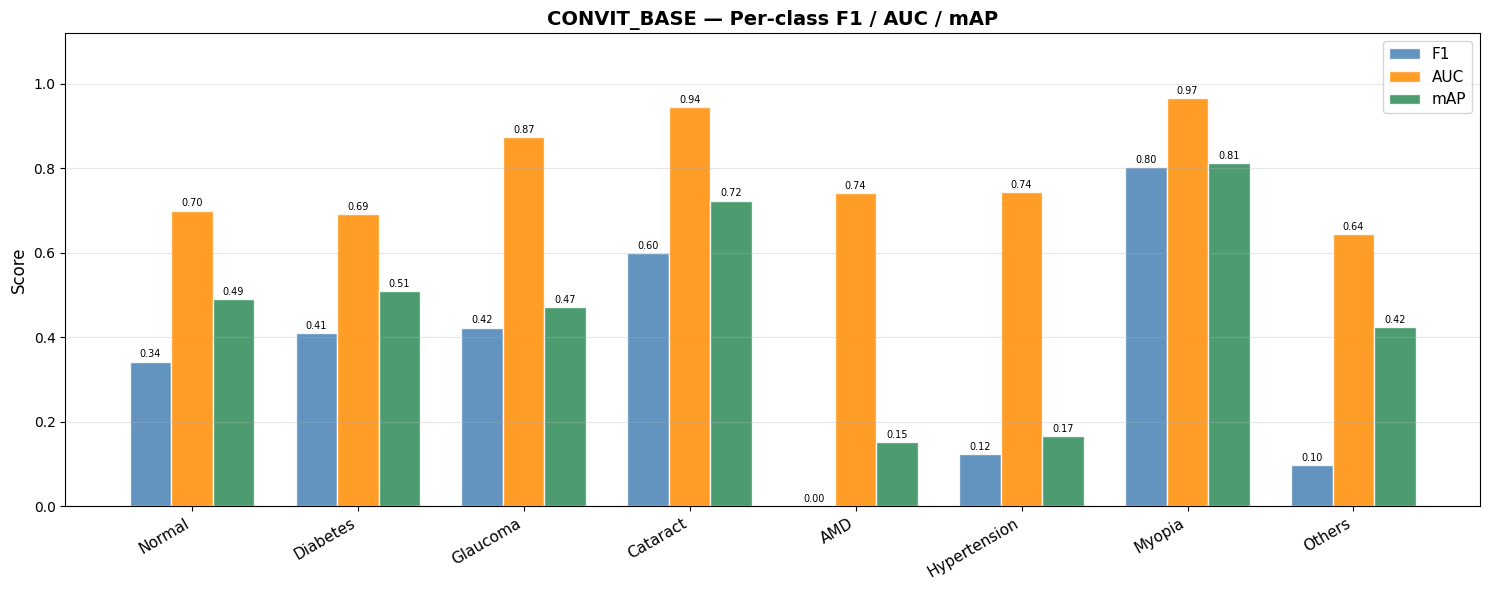

Saved: convit_base_metrics_bar.png


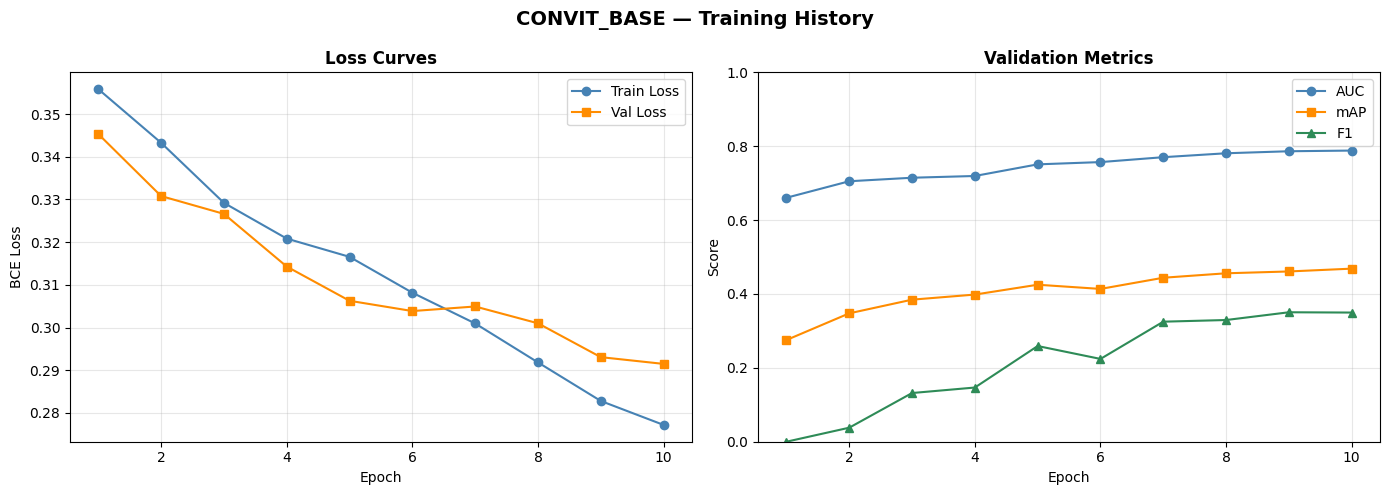

Saved: convit_base_training_curves.png
CUDA cache cleared.


In [3]:
# ============================================================
# MODEL 7: ConViT-Base — ODIR-5K Multi-Label Classification
# FIXED: Uses binary label columns directly, Affine instead of
#        ShiftScaleRotate, verified GPU usage
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
from torchmetrics.classification import (
    MultilabelAUROC, MultilabelAveragePrecision, MultilabelF1Score
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Config ───────────────────────────────────────────────────
MODEL_NAME   = "convit_base"
NUM_CLASSES  = 8
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Sanity-check GPU ─────────────────────────────────────────
print(f"Using device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Enable via Runtime → Change runtime type → GPU")

print(f"Model        : {MODEL_NAME}")

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract",
               "AMD",    "Hypertension", "Myopia", "Others"]

# Label columns already binarised in the Excel
LABEL_COLS  = ["N", "D", "G", "C", "A", "H", "M", "O"]

# ── Download Dataset ─────────────────────────────────────────
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")
print(f"Dataset path : {path}")

# ── Load Labels ──────────────────────────────────────────────
excel_candidates = glob(os.path.join(path, "**", "data.xlsx"), recursive=True)
assert len(excel_candidates) > 0, "data.xlsx not found!"
df = pd.read_excel(excel_candidates[0])
df.columns = [c.strip() for c in df.columns]
print(f"Excel shape  : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")

# ── Find image directory ──────────────────────────────────────
img_dirs = []
for root, dirs, files in os.walk(path):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(imgs) > 10:
        img_dirs.append((root, len(imgs)))
img_dirs.sort(key=lambda x: -x[1])
IMAGE_DIR = img_dirs[0][0]
print(f"Image dir    : {IMAGE_DIR}  ({img_dirs[0][1]} images)")

# ── Helper: resolve image path ───────────────────────────────
def resolve_path(fname):
    """Return full path for a filename, searching recursively if needed."""
    direct = os.path.join(IMAGE_DIR, fname)
    if os.path.exists(direct):
        return direct
    matches = glob(os.path.join(path, "**", fname), recursive=True)
    return matches[0] if matches else None

# ── Build per-eye sample list using binary label columns ──────
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

left_fname_col  = find_col(df, ["Left-Fundus",  "Left Fundus",  "left_fundus"])
right_fname_col = find_col(df, ["Right-Fundus", "Right Fundus", "right_fundus"])
assert left_fname_col  is not None, "Left-Fundus column not found"
assert right_fname_col is not None, "Right-Fundus column not found"
assert all(c in df.columns for c in LABEL_COLS), \
    f"Missing label columns. Found: {df.columns.tolist()}"

print(f"Left col     : {left_fname_col}")
print(f"Right col    : {right_fname_col}")
print(f"Label cols   : {LABEL_COLS}")

samples     = []
missing_cnt = 0

for _, row in df.iterrows():
    label_vec = [int(row[c]) for c in LABEL_COLS]   # already 0/1 integers

    for fname_col in [left_fname_col, right_fname_col]:
        fname = str(row[fname_col]).strip()
        fpath = resolve_path(fname)
        if fpath is None:
            missing_cnt += 1
            continue
        samples.append({"image_path": fpath, "labels": label_vec})

print(f"Total samples: {len(samples)}  (skipped {missing_cnt} missing images)")
assert len(samples) > 100, "Too few samples — check image paths!"

# ── Train / Val Split ─────────────────────────────────────────
train_samples, val_samples = train_test_split(
    samples, test_size=0.2, random_state=SEED
)
print(f"Train        : {len(train_samples)}  Val: {len(val_samples)}")

# ── Albumentations Transforms ─────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=10, p=0.3),
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.4
    ),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Dataset ───────────────────────────────────────────────────
class ODIRDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item  = self.samples[idx]
        image = np.array(Image.open(item["image_path"]).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        labels = torch.tensor(item["labels"], dtype=torch.float32)
        return image, labels

train_dataset = ODIRDataset(train_samples, train_transform)
val_dataset   = ODIRDataset(val_samples,   val_transform)

# pin_memory only useful with CUDA
_pin = DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=_pin)

# ── Model ─────────────────────────────────────────────────────
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")

# ── Loss / Optimizer / Scheduler ─────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── torchmetrics (kept on DEVICE for speed) ───────────────────
metric_auc = MultilabelAUROC(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_map = MultilabelAveragePrecision(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_f1  = MultilabelF1Score(num_labels=NUM_CLASSES, average="macro",
                                threshold=0.5).to(DEVICE)

# ── Train one epoch ───────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, desc="  Train", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}")
    return running_loss / len(loader.dataset)

# ── Validate ──────────────────────────────────────────────────
def validate(model, loader, criterion, device,
             metric_auc, metric_map, metric_f1):
    model.eval()
    running_loss = 0.0
    metric_auc.reset()
    metric_map.reset()
    metric_f1.reset()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Val  ", leave=False):
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            loss    = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            probs   = torch.sigmoid(logits)
            metric_auc.update(probs, labels.int())
            metric_map.update(probs, labels.int())
            metric_f1.update(probs,  labels.int())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    val_loss   = running_loss / len(loader.dataset)
    auc        = metric_auc.compute().item()
    mAP        = metric_map.compute().item()
    f1         = metric_f1.compute().item()
    all_probs  = torch.cat(all_probs,  dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return val_loss, auc, mAP, f1, all_probs, all_labels

# ── Training Loop ─────────────────────────────────────────────
best_auc    = 0.0
best_probs  = None
best_labels = None
history     = {"train_loss": [], "val_loss": [],
               "auc": [],       "map": [],      "f1": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch:02d}/{EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}")
    print("-" * 55)

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)

    val_loss, auc, mAP, f1, probs, labels = validate(
        model, val_loader, criterion, DEVICE,
        metric_auc, metric_map, metric_f1)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["auc"].append(auc)
    history["map"].append(mAP)
    history["f1"].append(f1)

    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Macro AUC  : {auc:.4f}")
    print(f"  Macro mAP  : {mAP:.4f}")
    print(f"  Macro F1   : {f1:.4f}")

    if auc > best_auc:
        best_auc    = auc
        best_probs  = probs.clone()
        best_labels = labels.clone()
        torch.save(model.state_dict(), f"best_{MODEL_NAME}.pth")
        print(f"  ✓ Best model saved  (AUC = {best_auc:.4f})")

print(f"\n{'='*55}")
print(f"Training complete.  Best Validation AUC : {best_auc:.4f}")
print(f"{'='*55}")

# ── Per-class metrics on best checkpoint ─────────────────────
best_probs_np  = best_probs.numpy()
best_labels_np = best_labels.numpy()
best_preds_np  = (best_probs_np >= 0.5).astype(int)

per_class_auc = []
per_class_map = []
per_class_f1  = []

for i in range(NUM_CLASSES):
    try:
        auc_i = roc_auc_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        auc_i = float("nan")
    try:
        map_i = average_precision_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        map_i = float("nan")
    f1_i = f1_score(best_labels_np[:, i], best_preds_np[:, i], zero_division=0)
    per_class_auc.append(auc_i)
    per_class_map.append(map_i)
    per_class_f1.append(f1_i)

print(f"\n{'Class':<15} {'AUC':>8} {'mAP':>8} {'F1':>8}")
print("-" * 42)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {per_class_auc[i]:>8.4f} "
          f"{per_class_map[i]:>8.4f} {per_class_f1[i]:>8.4f}")

# ── Plot 1: Per-class ROC Curves ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    if np.isnan(per_class_auc[i]):
        ax.text(0.5, 0.5, "N/A (single class)",
                ha="center", va="center", transform=ax.transAxes)
    else:
        fpr, tpr, _ = roc_curve(best_labels_np[:, i], best_probs_np[:, i])
        ax.plot(fpr, tpr, color="teal", lw=2,
                label=f"AUC = {per_class_auc[i]:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate",  fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Per-class ROC Curves",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_roc_curves.png")

# ── Plot 2: Bar chart F1 / AUC / mAP ─────────────────────────
x     = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
bars_f1  = ax.bar(x - width, per_class_f1,  width,
                  label="F1",  color="steelblue",  alpha=0.85, edgecolor="white")
bars_auc = ax.bar(x,          per_class_auc, width,
                  label="AUC", color="darkorange", alpha=0.85, edgecolor="white")
bars_map = ax.bar(x + width,  per_class_map, width,
                  label="mAP", color="seagreen",   alpha=0.85, edgecolor="white")

# Annotate bar tops
for bars in [bars_f1, bars_auc, bars_map]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h + 0.005,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"{MODEL_NAME.upper()} — Per-class F1 / AUC / mAP",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_metrics_bar.png")

# ── Plot 3: Training curves ───────────────────────────────────
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, history["train_loss"], "o-",
             label="Train Loss", color="steelblue")
axes[0].plot(epochs_x, history["val_loss"],   "s-",
             label="Val Loss",   color="darkorange")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["auc"], "o-", label="AUC", color="steelblue")
axes[1].plot(epochs_x, history["map"], "s-", label="mAP", color="darkorange")
axes[1].plot(epochs_x, history["f1"],  "^-", label="F1",  color="seagreen")
axes[1].set_title("Validation Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Training History",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_training_curves.png")

# ── Cleanup ───────────────────────────────────────────────────
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared.")

Using device : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
Model        : maxvit_base_tf_224
Using Colab cache for faster access to the 'ocular-disease-recognition-odir5k' dataset.
Dataset path : /kaggle/input/ocular-disease-recognition-odir5k
Excel shape  : (3500, 15)
Columns      : ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Image dir    : /kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images  (7000 images)
Left col     : Left-Fundus
Right col    : Right-Fundus
Label cols   : ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Total samples: 7000  (skipped 0 missing images)
Train        : 5600  Val: 1400


model.safetensors:   0%|          | 0.00/479M [00:00<?, ?B/s]

Parameters   : 118,704,860

Epoch [01/10]  lr=3.00e-04
-------------------------------------------------------


  Train Loss : 0.3168
  Val   Loss : 0.2826
  Macro AUC  : 0.8060
  Macro mAP  : 0.5058
  Macro F1   : 0.3389
  ✓ Best model saved  (AUC = 0.8060)

Epoch [02/10]  lr=2.93e-04
-------------------------------------------------------


  Train Loss : 0.2826
  Val   Loss : 0.2786
  Macro AUC  : 0.8248
  Macro mAP  : 0.5537
  Macro F1   : 0.4403
  ✓ Best model saved  (AUC = 0.8248)

Epoch [03/10]  lr=2.71e-04
-------------------------------------------------------


...

  Train Loss : 0.2022
  Val   Loss : 0.2573
  Macro AUC  : 0.8550
  Macro mAP  : 0.6312
  Macro F1   : 0.5825
  ✓ Best model saved  (AUC = 0.8550)

Epoch [07/10]  lr=1.04e-04
-------------------------------------------------------


  Train Loss : 0.1705
  Val   Loss : 0.2688
  Macro AUC  : 0.8575
  Macro mAP  : 0.6090
  Macro F1   : 0.5784
  ✓ Best model saved  (AUC = 0.8575)

Epoch [08/10]  lr=6.18e-05
-------------------------------------------------------


  Train Loss : 0.1327
  Val   Loss : 0.2987
  Macro AUC  : 0.8532
  Macro mAP  : 0.5881
  Macro F1   : 0.5796

Epoch [09/10]  lr=2.86e-05
-------------------------------------------------------


  Train Loss : 0.1027
  Val   Loss : 0.3144
  Macro AUC  : 0.8522
  Macro mAP  : 0.6039
  Macro F1   : 0.5738

Epoch [10/10]  lr=7.34e-06
-------------------------------------------------------


  Train Loss : 0.0859
  Val   Loss : 0.3212
  Macro AUC  : 0.8535
  Macro mAP  : 0.6034
  Macro F1   : 0.5811

Training complete.  Best Validation AUC : 0.8575

Class                AUC      mAP       F1
------------------------------------------
Normal            0.7844   0.5661   0.4729
Diabetes          0.8043   0.7378   0.6130
Glaucoma          0.8966   0.4809   0.5248
Cataract          0.9339   0.7232   0.7582
AMD               0.8606   0.5586   0.5859
Hypertension      0.8601   0.3477   0.3607
Myopia            0.9595   0.8342   0.8154
Others            0.7607   0.6232   0.4965


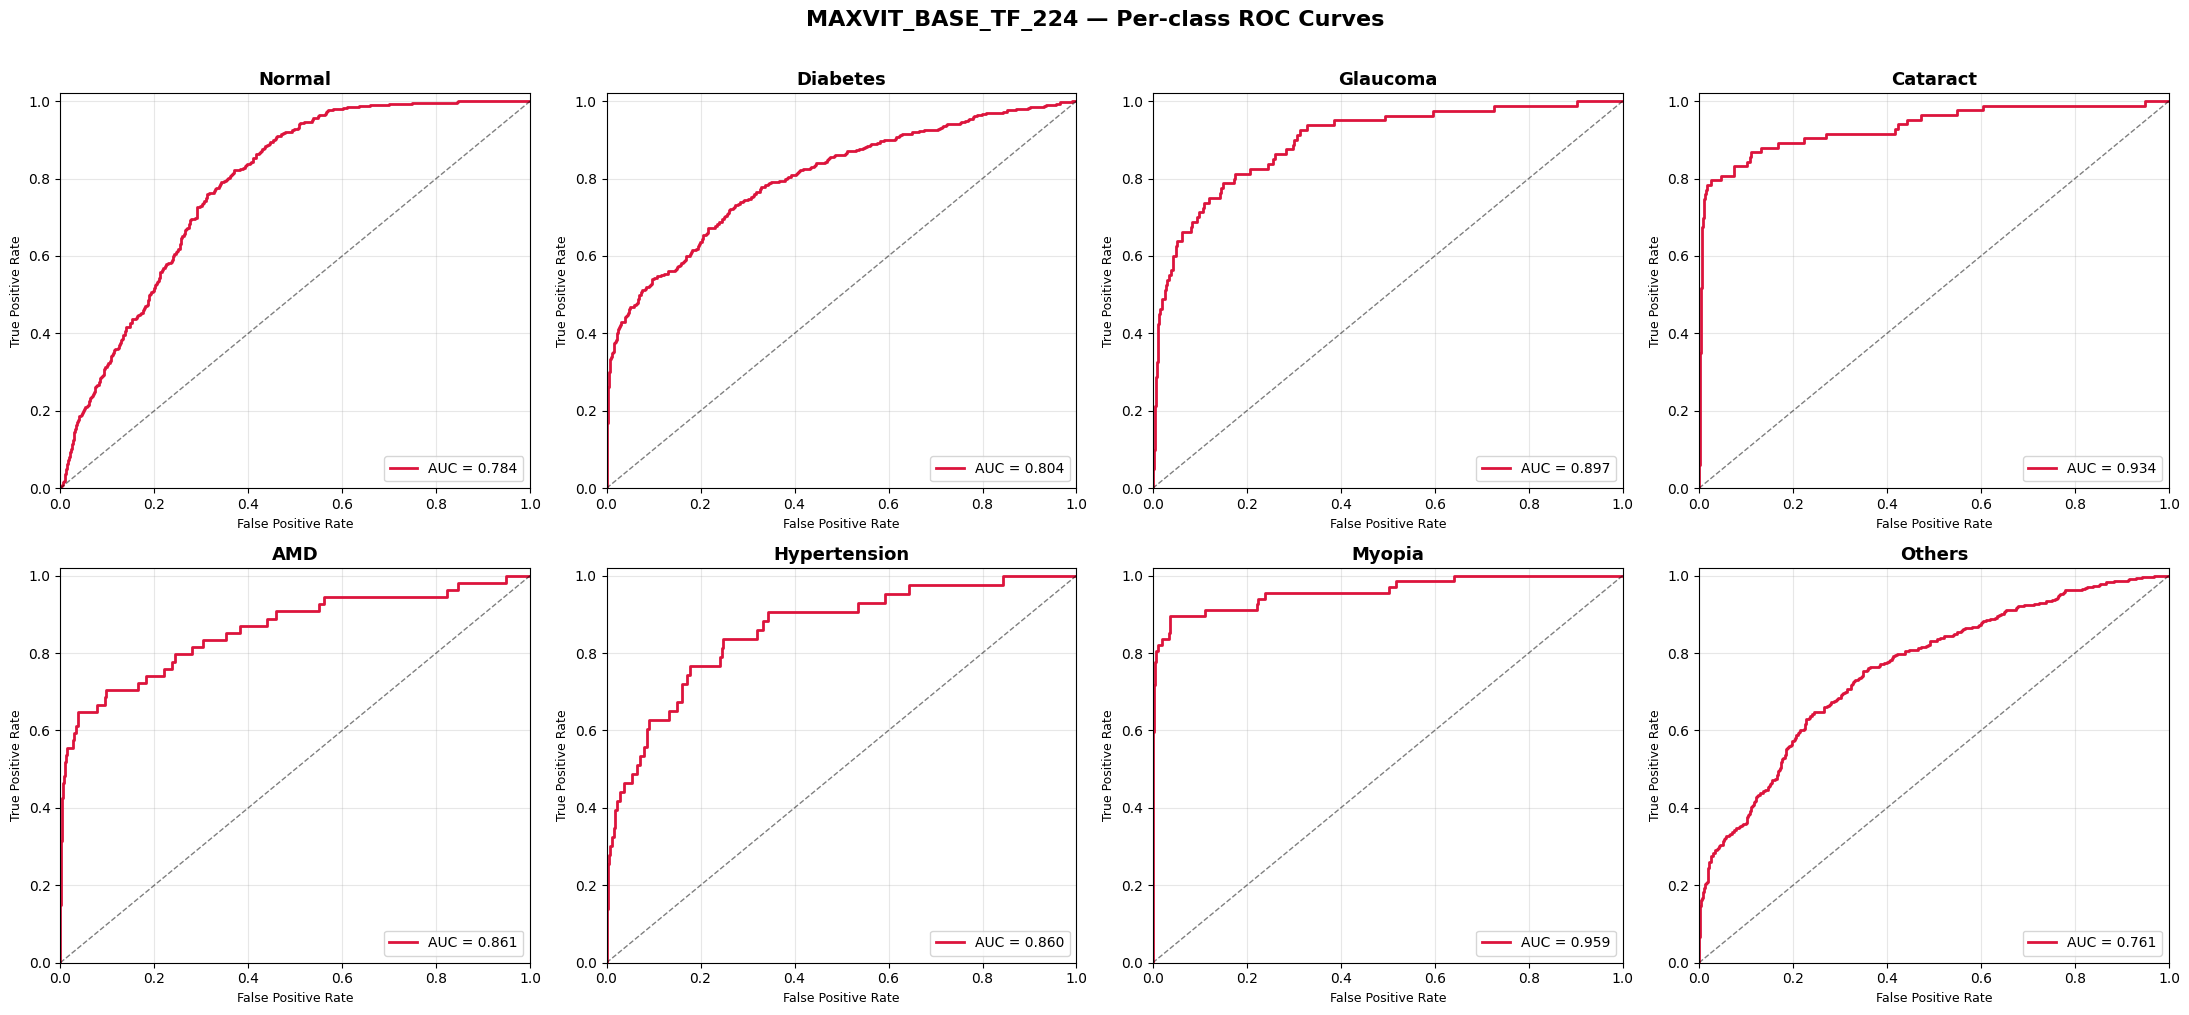

Saved: maxvit_base_tf_224_roc_curves.png


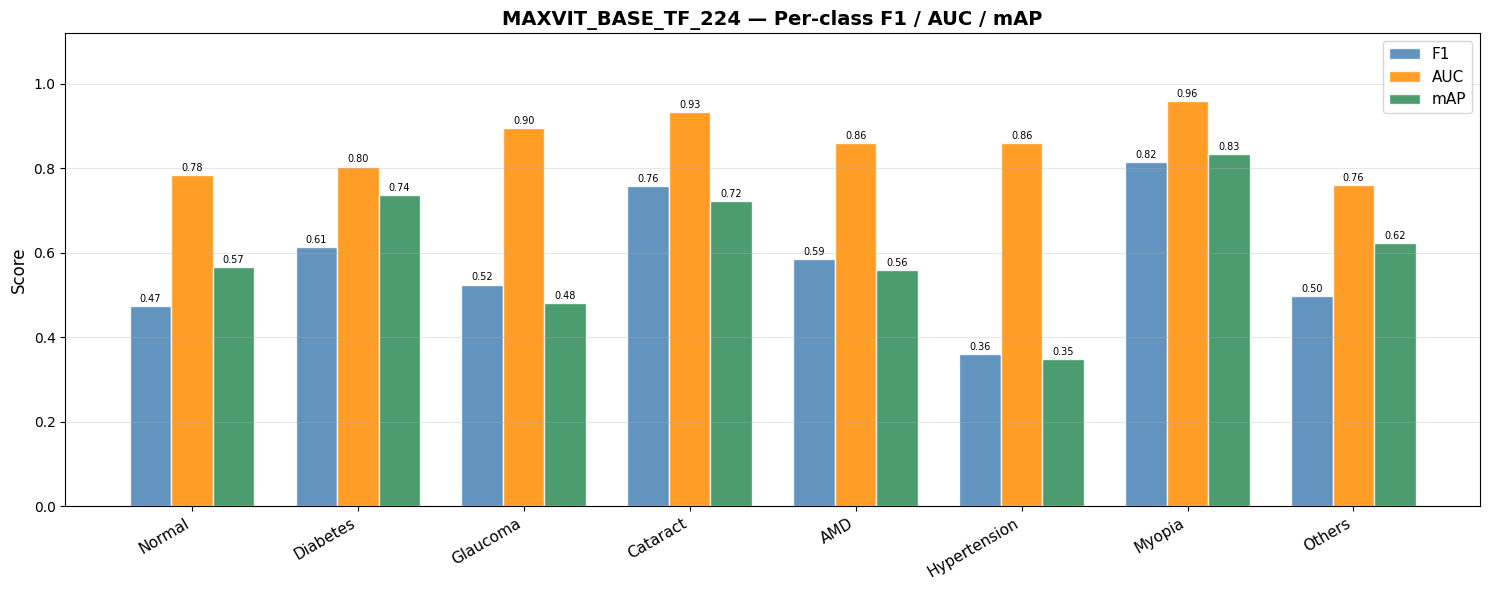

Saved: maxvit_base_tf_224_metrics_bar.png


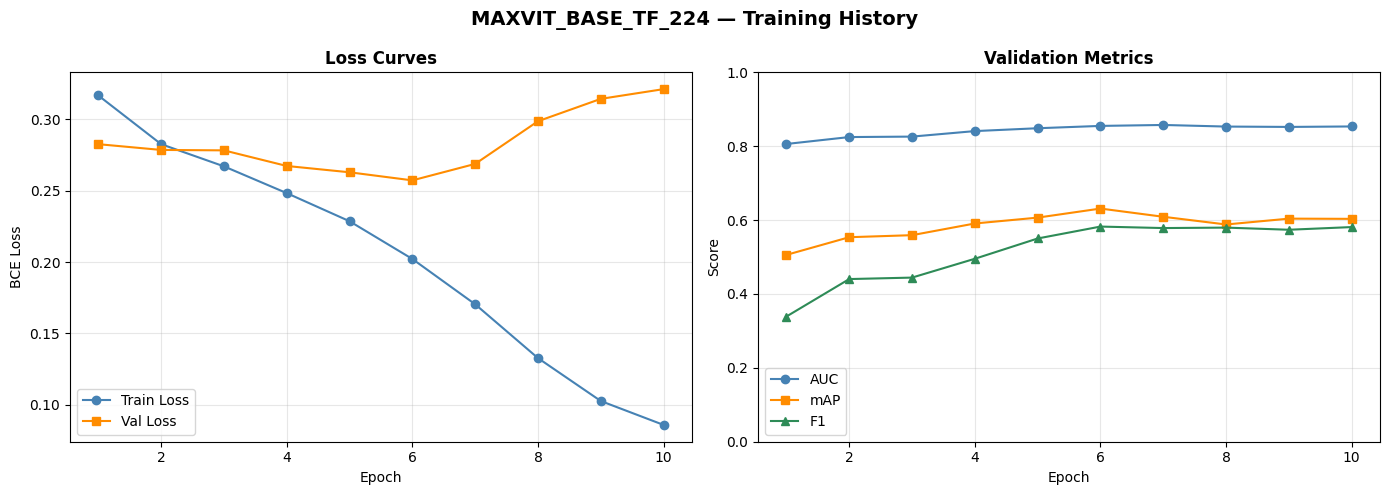

Saved: maxvit_base_tf_224_training_curves.png
CUDA cache cleared.


In [5]:
# ============================================================
# MODEL 8: MaxViT-Base — ODIR-5K Multi-Label Classification
# FIXED: Uses binary label columns directly, Affine instead of
#        ShiftScaleRotate, verified GPU usage
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
from torchmetrics.classification import (
    MultilabelAUROC, MultilabelAveragePrecision, MultilabelF1Score
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Config ───────────────────────────────────────────────────
MODEL_NAME   = "maxvit_base_tf_224"
NUM_CLASSES  = 8
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Sanity-check GPU ─────────────────────────────────────────
print(f"Using device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Enable via Runtime → Change runtime type → GPU")

print(f"Model        : {MODEL_NAME}")

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract",
               "AMD",    "Hypertension", "Myopia", "Others"]

# Label columns already binarised in the Excel
LABEL_COLS  = ["N", "D", "G", "C", "A", "H", "M", "O"]

# ── Download Dataset ─────────────────────────────────────────
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")
print(f"Dataset path : {path}")

# ── Load Labels ──────────────────────────────────────────────
excel_candidates = glob(os.path.join(path, "**", "data.xlsx"), recursive=True)
assert len(excel_candidates) > 0, "data.xlsx not found!"
df = pd.read_excel(excel_candidates[0])
df.columns = [c.strip() for c in df.columns]
print(f"Excel shape  : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")

# ── Find image directory ──────────────────────────────────────
img_dirs = []
for root, dirs, files in os.walk(path):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(imgs) > 10:
        img_dirs.append((root, len(imgs)))
img_dirs.sort(key=lambda x: -x[1])
IMAGE_DIR = img_dirs[0][0]
print(f"Image dir    : {IMAGE_DIR}  ({img_dirs[0][1]} images)")

# ── Helper: resolve image path ───────────────────────────────
def resolve_path(fname):
    """Return full path for a filename, searching recursively if needed."""
    direct = os.path.join(IMAGE_DIR, fname)
    if os.path.exists(direct):
        return direct
    matches = glob(os.path.join(path, "**", fname), recursive=True)
    return matches[0] if matches else None

# ── Build per-eye sample list using binary label columns ──────
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

left_fname_col  = find_col(df, ["Left-Fundus",  "Left Fundus",  "left_fundus"])
right_fname_col = find_col(df, ["Right-Fundus", "Right Fundus", "right_fundus"])
assert left_fname_col  is not None, "Left-Fundus column not found"
assert right_fname_col is not None, "Right-Fundus column not found"
assert all(c in df.columns for c in LABEL_COLS), \
    f"Missing label columns. Found: {df.columns.tolist()}"

print(f"Left col     : {left_fname_col}")
print(f"Right col    : {right_fname_col}")
print(f"Label cols   : {LABEL_COLS}")

samples     = []
missing_cnt = 0

for _, row in df.iterrows():
    label_vec = [int(row[c]) for c in LABEL_COLS]   # already 0/1 integers

    for fname_col in [left_fname_col, right_fname_col]:
        fname = str(row[fname_col]).strip()
        fpath = resolve_path(fname)
        if fpath is None:
            missing_cnt += 1
            continue
        samples.append({"image_path": fpath, "labels": label_vec})

print(f"Total samples: {len(samples)}  (skipped {missing_cnt} missing images)")
assert len(samples) > 100, "Too few samples — check image paths!"

# ── Train / Val Split ─────────────────────────────────────────
train_samples, val_samples = train_test_split(
    samples, test_size=0.2, random_state=SEED
)
print(f"Train        : {len(train_samples)}  Val: {len(val_samples)}")

# ── Albumentations Transforms ─────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=10, p=0.3),
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.4
    ),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Dataset ───────────────────────────────────────────────────
class ODIRDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item  = self.samples[idx]
        image = np.array(Image.open(item["image_path"]).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        labels = torch.tensor(item["labels"], dtype=torch.float32)
        return image, labels

train_dataset = ODIRDataset(train_samples, train_transform)
val_dataset   = ODIRDataset(val_samples,   val_transform)

# pin_memory only useful with CUDA
_pin = DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=_pin)

# ── Model ─────────────────────────────────────────────────────
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")

# ── Loss / Optimizer / Scheduler ─────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── torchmetrics (kept on DEVICE for speed) ───────────────────
metric_auc = MultilabelAUROC(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_map = MultilabelAveragePrecision(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_f1  = MultilabelF1Score(num_labels=NUM_CLASSES, average="macro",
                                threshold=0.5).to(DEVICE)

# ── Train one epoch ───────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, desc="  Train", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}")
    return running_loss / len(loader.dataset)

# ── Validate ──────────────────────────────────────────────────
def validate(model, loader, criterion, device,
             metric_auc, metric_map, metric_f1):
    model.eval()
    running_loss = 0.0
    metric_auc.reset()
    metric_map.reset()
    metric_f1.reset()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Val  ", leave=False):
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            loss    = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            probs   = torch.sigmoid(logits)
            metric_auc.update(probs, labels.int())
            metric_map.update(probs, labels.int())
            metric_f1.update(probs,  labels.int())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    val_loss   = running_loss / len(loader.dataset)
    auc        = metric_auc.compute().item()
    mAP        = metric_map.compute().item()
    f1         = metric_f1.compute().item()
    all_probs  = torch.cat(all_probs,  dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return val_loss, auc, mAP, f1, all_probs, all_labels

# ── Training Loop ─────────────────────────────────────────────
best_auc    = 0.0
best_probs  = None
best_labels = None
history     = {"train_loss": [], "val_loss": [],
               "auc": [],       "map": [],      "f1": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch:02d}/{EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}")
    print("-" * 55)

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)

    val_loss, auc, mAP, f1, probs, labels = validate(
        model, val_loader, criterion, DEVICE,
        metric_auc, metric_map, metric_f1)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["auc"].append(auc)
    history["map"].append(mAP)
    history["f1"].append(f1)

    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Macro AUC  : {auc:.4f}")
    print(f"  Macro mAP  : {mAP:.4f}")
    print(f"  Macro F1   : {f1:.4f}")

    if auc > best_auc:
        best_auc    = auc
        best_probs  = probs.clone()
        best_labels = labels.clone()
        torch.save(model.state_dict(), f"best_{MODEL_NAME}.pth")
        print(f"  ✓ Best model saved  (AUC = {best_auc:.4f})")

print(f"\n{'='*55}")
print(f"Training complete.  Best Validation AUC : {best_auc:.4f}")
print(f"{'='*55}")

# ── Per-class metrics on best checkpoint ─────────────────────
best_probs_np  = best_probs.numpy()
best_labels_np = best_labels.numpy()
best_preds_np  = (best_probs_np >= 0.5).astype(int)

per_class_auc = []
per_class_map = []
per_class_f1  = []

for i in range(NUM_CLASSES):
    try:
        auc_i = roc_auc_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        auc_i = float("nan")
    try:
        map_i = average_precision_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        map_i = float("nan")
    f1_i = f1_score(best_labels_np[:, i], best_preds_np[:, i], zero_division=0)
    per_class_auc.append(auc_i)
    per_class_map.append(map_i)
    per_class_f1.append(f1_i)

print(f"\n{'Class':<15} {'AUC':>8} {'mAP':>8} {'F1':>8}")
print("-" * 42)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {per_class_auc[i]:>8.4f} "
          f"{per_class_map[i]:>8.4f} {per_class_f1[i]:>8.4f}")

# ── Plot 1: Per-class ROC Curves ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    if np.isnan(per_class_auc[i]):
        ax.text(0.5, 0.5, "N/A (single class)",
                ha="center", va="center", transform=ax.transAxes)
    else:
        fpr, tpr, _ = roc_curve(best_labels_np[:, i], best_probs_np[:, i])
        ax.plot(fpr, tpr, color="crimson", lw=2,
                label=f"AUC = {per_class_auc[i]:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate",  fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Per-class ROC Curves",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_roc_curves.png")

# ── Plot 2: Bar chart F1 / AUC / mAP ─────────────────────────
x     = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
bars_f1  = ax.bar(x - width, per_class_f1,  width,
                  label="F1",  color="steelblue",  alpha=0.85, edgecolor="white")
bars_auc = ax.bar(x,          per_class_auc, width,
                  label="AUC", color="darkorange", alpha=0.85, edgecolor="white")
bars_map = ax.bar(x + width,  per_class_map, width,
                  label="mAP", color="seagreen",   alpha=0.85, edgecolor="white")

# Annotate bar tops
for bars in [bars_f1, bars_auc, bars_map]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h + 0.005,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"{MODEL_NAME.upper()} — Per-class F1 / AUC / mAP",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_metrics_bar.png")

# ── Plot 3: Training curves ───────────────────────────────────
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, history["train_loss"], "o-",
             label="Train Loss", color="steelblue")
axes[0].plot(epochs_x, history["val_loss"],   "s-",
             label="Val Loss",   color="darkorange")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["auc"], "o-", label="AUC", color="steelblue")
axes[1].plot(epochs_x, history["map"], "s-", label="mAP", color="darkorange")
axes[1].plot(epochs_x, history["f1"],  "^-", label="F1",  color="seagreen")
axes[1].set_title("Validation Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Training History",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_training_curves.png")

# ── Cleanup ───────────────────────────────────────────────────
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared.")